- Import suatu library yang di perlukan

    pandas → library untuk manipulasi dan analisis data.

    Matplotlib → library untuk membuat grafik/visualisasi.
- Membuat data manual
- Menampilkan data yang telah dibuat

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.style.use("seaborn-v0_8-whitegrid")

data = {
    "Products": [
        "T-Shirt",
        "Jeans",
        "Sneakers",
        "Jacket",
        "Hat",
        "Gloves",
        "Socks",
        "Scarf",
        "Belt",
        "Sunglasses",
    ],
    "Price": [20000, 50000, 75000, 100000, 15000, 8000, 5000, 12000, 15000, 25000],
    "Total_Sales": [100, 80, 60, 40, 120, 90, 70, 110, 85, 95],
}

df = pd.DataFrame(data)
df

,Products,Price,Total_Sales
0,T-Shirt,20000,100
1,Jeans,50000,80
2,Sneakers,75000,60
3,Jacket,100000,40
4,Hat,15000,120
5,Gloves,8000,90
6,Socks,5000,70
7,Scarf,12000,110
8,Belt,15000,85
9,Sunglasses,25000,95


Menampilkan data 5 teratas

In [5]:
df.head(5)

,Products,Price,Total_Sales
0,T-Shirt,20000,100
1,Jeans,50000,80
2,Sneakers,75000,60
3,Jacket,100000,40
4,Hat,15000,120


Menampilkan data statistik

In [6]:
df.describe(include="all")

,Products,Price,Total_Sales
count,10,10.000000,10.000000
unique,10,NaN,NaN
top,T-Shirt,NaN,NaN
freq,1,NaN,NaN
mean,NaN,32500.000000,85.000000
std,NaN,32094.478584,23.804761
min,NaN,5000.000000,40.000000
25%,NaN,12750.000000,72.500000
50%,NaN,17500.000000,87.500000
75%,NaN,43750.000000,98.750000


Menampilkan data kolom tertentu sesuai yang di panggil

In [7]:
df["Price"]

0     20000
1     50000
2     75000
3    100000
4     15000
5      8000
6      5000
7     12000
8     15000
9     25000
Name: Price, dtype: int64

Filtering data dari teratas hingga terkecil

In [8]:
df.sort_values(by="Total_Sales", ascending=False)

,Products,Price,Total_Sales
4,Hat,15000,120
7,Scarf,12000,110
0,T-Shirt,20000,100
9,Sunglasses,25000,95
5,Gloves,8000,90
8,Belt,15000,85
1,Jeans,50000,80
6,Socks,5000,70
2,Sneakers,75000,60
3,Jacket,100000,40


**Manipulasi Data**

- Tambahkan kolom Total_Penjualan yang dihitung dari harga × jumlah.
- Tambahkan kolom baru bernama Diskon_10% yang nilainya 10% dari Total_Penjualan.
- Tambahkan kolom Pendapatan_Bersih setelah diskon.
- Rata-rata Produk dan pendapatan bersih.

In [9]:
df["Sum_Sales"] = df["Price"] * df["Total_Sales"]
df

,Products,Price,Total_Sales,Sum_Sales
0,T-Shirt,20000,100,2000000
1,Jeans,50000,80,4000000
2,Sneakers,75000,60,4500000
3,Jacket,100000,40,4000000
4,Hat,15000,120,1800000
5,Gloves,8000,90,720000
6,Socks,5000,70,350000
7,Scarf,12000,110,1320000
8,Belt,15000,85,1275000
9,Sunglasses,25000,95,2375000


In [10]:
df["Discount_10%"] = df["Sum_Sales"] * 0.10
df

,Products,Price,Total_Sales,Sum_Sales,Discount_10%
0,T-Shirt,20000,100,2000000,200000.0
1,Jeans,50000,80,4000000,400000.0
2,Sneakers,75000,60,4500000,450000.0
3,Jacket,100000,40,4000000,400000.0
4,Hat,15000,120,1800000,180000.0
5,Gloves,8000,90,720000,72000.0
6,Socks,5000,70,350000,35000.0
7,Scarf,12000,110,1320000,132000.0
8,Belt,15000,85,1275000,127500.0
9,Sunglasses,25000,95,2375000,237500.0


In [11]:
df["Net_Income"] = df["Sum_Sales"] - df["Discount_10%"]
df

,Products,Price,Total_Sales,Sum_Sales,Discount_10%,Net_Income
0,T-Shirt,20000,100,2000000,200000.0,1800000.0
1,Jeans,50000,80,4000000,400000.0,3600000.0
2,Sneakers,75000,60,4500000,450000.0,4050000.0
3,Jacket,100000,40,4000000,400000.0,3600000.0
4,Hat,15000,120,1800000,180000.0,1620000.0
5,Gloves,8000,90,720000,72000.0,648000.0
6,Socks,5000,70,350000,35000.0,315000.0
7,Scarf,12000,110,1320000,132000.0,1188000.0
8,Belt,15000,85,1275000,127500.0,1147500.0
9,Sunglasses,25000,95,2375000,237500.0,2137500.0


In [12]:
average_item_product = df.groupby("Products")["Net_Income"].mean()
average_item_product

Products
Belt          1147500.0
Gloves         648000.0
Hat           1620000.0
Jacket        3600000.0
Jeans         3600000.0
Scarf         1188000.0
Sneakers      4050000.0
Socks          315000.0
Sunglasses    2137500.0
T-Shirt       1800000.0
Name: Net_Income, dtype: float64

In [13]:
average_net_income = df["Net_Income"].mean()
print(f"Average Net Income: {average_net_income}")

Average Net Income: 2010600.0


**Visualisasi**

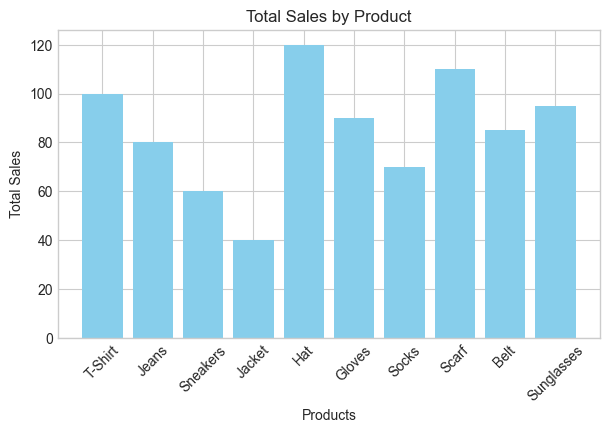

In [14]:
plt.bar(df["Products"], df["Total_Sales"], color="skyblue")
plt.xlabel("Products")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product")
plt.xticks(rotation=45)
plt.show()

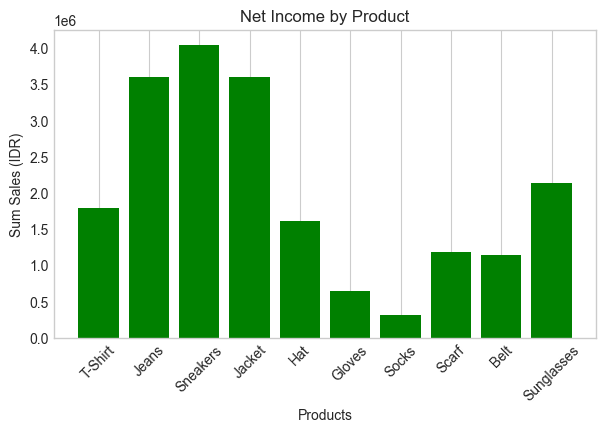

In [15]:
plt.bar(df["Products"], df["Net_Income"], color="green")
plt.xlabel("Products")
plt.ylabel("Sum Sales (IDR)")
plt.title("Net Income by Product")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

<Axes: title={'center': 'Average Net Income by Product'}, xlabel='Products'>

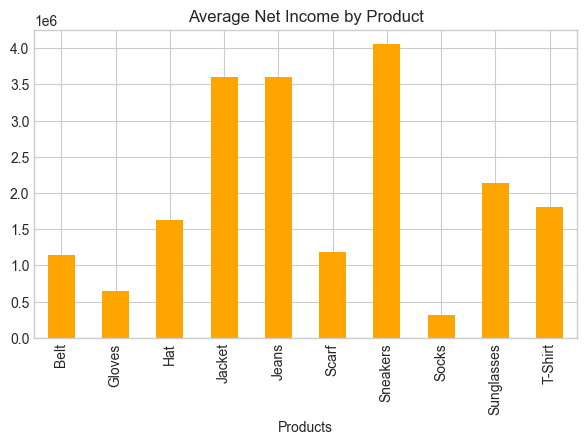

In [16]:
average_item_product = df.groupby("Products")["Net_Income"].mean()
average_item_product.plot(
    kind="bar", color="orange", title="Average Net Income by Product"
)

**Studi Kasus**

In [17]:
new_data = {
    "Title Film": [
        "Ratatouille",
        "Toy Story",
        "Finding Nemo",
        "The Incredibles",
        "Cars",
        "Up",
        "WALL-E",
        "Inside Out",
        " Monsters, Inc.",
        "Tangled",
    ],
    "Price": [
        150000,
        120000,
        130000,
        140000,
        110000,
        160000,
        125000,
        135000,
        115000,
        145000,
    ],
    "Ticket Sales": [500, 600, 550, 450, 700, 400, 650, 480, 520, 430],
}

new_df = pd.DataFrame(new_data)
new_df

,Title Film,Price,Ticket Sales
0,Ratatouille,150000,500
1,Toy Story,120000,600
2,Finding Nemo,130000,550
3,The Incredibles,140000,450
4,Cars,110000,700
5,Up,160000,400
6,WALL-E,125000,650
7,Inside Out,135000,480
8,"Monsters, Inc.",115000,520
9,Tangled,145000,430


Data statistik

In [28]:
new_df.describe(include="all")

,Title Film,Price,Ticket Sales,Gross Income,Discount Promotional,Net Income
count,10,10.000000,10.000000,1.000000e+01,1.000000e+01,1.000000e+01
unique,10,NaN,NaN,NaN,NaN,NaN
top,Ratatouille,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,133000.000000,528.000000,6.907000e+07,6.907000e+06,6.216300e+07
std,NaN,16020.819788,97.388112,7.247728e+06,7.247728e+05,6.522955e+06
min,NaN,110000.000000,400.000000,5.980000e+07,5.980000e+06,5.382000e+07
25%,NaN,121250.000000,457.500000,6.325000e+07,6.325000e+06,5.692500e+07
50%,NaN,132500.000000,510.000000,6.815000e+07,6.815000e+06,6.133500e+07
75%,NaN,143750.000000,587.500000,7.425000e+07,7.425000e+06,6.682500e+07


**Manipulasi Data**
1. Tambah kolom pendapatan kotor
2. Diskon 10%
3. Tambah kolom pendapatan bersih

In [19]:
new_df["Gross Income"] = new_df["Price"] * new_df["Ticket Sales"]
new_df

,Title Film,Price,Ticket Sales,Gross Income
0,Ratatouille,150000,500,75000000
1,Toy Story,120000,600,72000000
2,Finding Nemo,130000,550,71500000
3,The Incredibles,140000,450,63000000
4,Cars,110000,700,77000000
5,Up,160000,400,64000000
6,WALL-E,125000,650,81250000
7,Inside Out,135000,480,64800000
8,"Monsters, Inc.",115000,520,59800000
9,Tangled,145000,430,62350000


In [20]:
new_df["Discount Promotional"] = new_df["Gross Income"] * 0.10
new_df

,Title Film,Price,Ticket Sales,Gross Income,Discount Promotional
0,Ratatouille,150000,500,75000000,7500000.0
1,Toy Story,120000,600,72000000,7200000.0
2,Finding Nemo,130000,550,71500000,7150000.0
3,The Incredibles,140000,450,63000000,6300000.0
4,Cars,110000,700,77000000,7700000.0
5,Up,160000,400,64000000,6400000.0
6,WALL-E,125000,650,81250000,8125000.0
7,Inside Out,135000,480,64800000,6480000.0
8,"Monsters, Inc.",115000,520,59800000,5980000.0
9,Tangled,145000,430,62350000,6235000.0


In [21]:
new_df["Net Income"] = new_df["Gross Income"] - new_df["Discount Promotional"]
new_df

,Title Film,Price,Ticket Sales,Gross Income,Discount Promotional,Net Income
0,Ratatouille,150000,500,75000000,7500000.0,67500000.0
1,Toy Story,120000,600,72000000,7200000.0,64800000.0
2,Finding Nemo,130000,550,71500000,7150000.0,64350000.0
3,The Incredibles,140000,450,63000000,6300000.0,56700000.0
4,Cars,110000,700,77000000,7700000.0,69300000.0
5,Up,160000,400,64000000,6400000.0,57600000.0
6,WALL-E,125000,650,81250000,8125000.0,73125000.0
7,Inside Out,135000,480,64800000,6480000.0,58320000.0
8,"Monsters, Inc.",115000,520,59800000,5980000.0,53820000.0
9,Tangled,145000,430,62350000,6235000.0,56115000.0


**Rata-rata
Pendapatan Maksimal dan Minimal**

In [22]:
print("\nNet Income for Each Film:")
print(new_df[["Title Film", "Net Income"]])


Net Income for Each Film:
        Title Film  Net Income
0      Ratatouille  67500000.0
1        Toy Story  64800000.0
2     Finding Nemo  64350000.0
3  The Incredibles  56700000.0
4             Cars  69300000.0
5               Up  57600000.0
6           WALL-E  73125000.0
7       Inside Out  58320000.0
8   Monsters, Inc.  53820000.0
9          Tangled  56115000.0


In [23]:
average = new_df["Net Income"].mean()
print(f"\nAverage Net Income: {average}")


Average Net Income: 62163000.0


In [24]:
max = new_df["Net Income"].max()
print(f"\nMaximum Net Income: {max}")

min = new_df["Net Income"].min()
print(f"\nMinimum Net Income: {min}")


Maximum Net Income: 73125000.0

Minimum Net Income: 53820000.0


**Visualisasi**

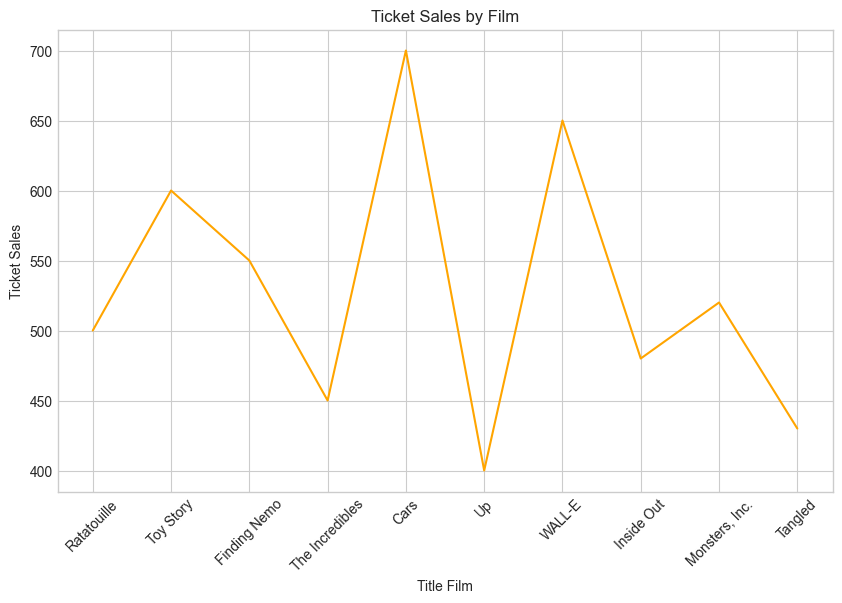

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(new_df["Title Film"], new_df["Ticket Sales"], color="orange")

plt.title("Ticket Sales by Film")
plt.xlabel("Title Film")
plt.ylabel("Ticket Sales")
plt.xticks(rotation=45)
plt.show()

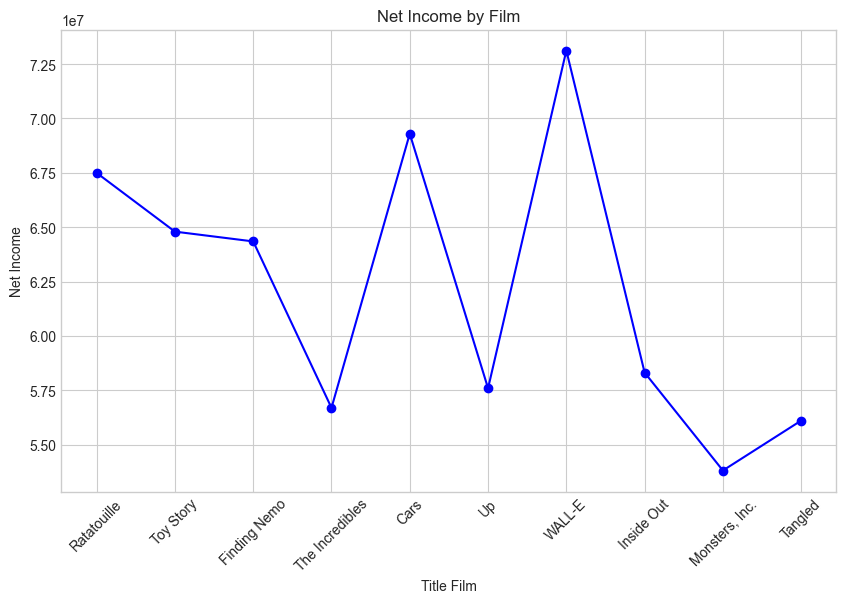

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(
    new_df["Title Film"], new_df["Net Income"], marker="o", linestyle="-", color="blue"
)
plt.title("Net Income by Film")
plt.xlabel("Title Film")
plt.ylabel("Net Income")
plt.xticks(rotation=45)
plt.show()

In [27]:
sum_films = new_df["Title Film"].count()

print(f"\nTotal Number of Films: {sum_films}")


Total Number of Films: 10
